Importing Libraries:

In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Importing Dataset


In [4]:
meta = pd.read_csv('app_metadata_clean.csv')
reviews = pd.read_csv('raw_reviews_clean.csv')
perms = pd.read_csv('permissions_filled.csv')

In [ ]:
print("Metadata shape:", meta.shape)
print("Reviews shape:", reviews.shape)
print("Permissions shape:", perms.shape)


Metadata shape: (84, 8)
Reviews shape: (3577, 5)
Permissions shape: (84, 11)


Merge Permission into MetaData

In [6]:
meta = meta.merge(
    perms[['app_id', 'contacts', 'sms', 'microphone', 'location', 'photos_media_storage']],
    on='app_id', how='left'
)

Feature Engineering:

Disclosure Completeness Score
- Checks the app's description text for 5 things a transparent lender should disclose:
- interest rate, tenure, RBI/NBFC registration, grievance contact, privacy policy link

In [7]:
def disclosure_score(row):
    desc = str(row['description']).lower()
    has_rate    = bool(re.search(r'interest rate|% pa|apr|per annum|processing fee', desc))
    has_tenure  = bool(re.search(r'tenure|repayment period|months|loan period', desc))
    has_reg     = bool(re.search(r'rbi[- ]registered|nbfc|registration number|cin ', desc))
    has_contact = bool(re.search(r'customer care|grievance|support@|contact us|helpline', desc))
    pp = str(row['privacy_policy'])
    has_pp = pp not in ('nan', '', 'None') and 'http' in pp
    return has_rate + has_tenure + has_reg + has_contact + has_pp

meta['disclosure_score'] = meta.apply(disclosure_score, axis=1)

Review Red-Flag Score
- % of an app's reviews that contain harassment/coercion-related keywords
- (the specific language RBI-flagged predatory apps' victims commonly use)

In [8]:
REDFLAG_KEYWORDS = [
    'harass', 'threat', 'blackmail', 'recovery agent', 'shared my contact',
    'shared my photo', 'called my family', 'called my office', 'called my boss',
    'defame', 'morphed', 'abuse', 'extort', 'humiliate', 'fake photo',
    'contacted my', 'leak my photo', 'suicide', 'fraud app', 'scam',
    'collecting data', 'ask reference', 'visit my work', 'threatening'
]
pattern = re.compile('|'.join(re.escape(k) for k in REDFLAG_KEYWORDS), re.I)
reviews['is_redflag'] = reviews['review_text'].astype(str).str.contains(pattern)

redflag_summary = reviews.groupby('app_id').agg(
    total_reviews=('review_text', 'count'),
    redflag_reviews=('is_redflag', 'sum')
).reset_index()
redflag_summary['review_redflag_score'] = (
    redflag_summary['redflag_reviews'] / redflag_summary['total_reviews']
).round(3)

Sentiment Score
- in our testing, general sentiment came out INVERTED (predatory apps
often show more positive sentiment overall — possibly fake/boosted reviews,
while legit big-bank apps get more negative reviews about unrelated bugs).


In [9]:
analyzer = SentimentIntensityAnalyzer()
reviews['sentiment'] = reviews['review_text'].astype(str).apply(
    lambda t: analyzer.polarity_scores(t)['compound']
)
sentiment_summary = reviews.groupby('app_id')['sentiment'].mean().reset_index() \
    .rename(columns={'sentiment': 'avg_review_sentiment'})

reviews['strongly_negative'] = reviews['sentiment'] < -0.5
neg_pct = reviews.groupby('app_id')['strongly_negative'].mean().reset_index() \
    .rename(columns={'strongly_negative': 'pct_strongly_negative_reviews'})


Review Length

In [10]:
reviews['review_word_count'] = reviews['review_text'].astype(str).str.split().str.len()
review_len = reviews.groupby('app_id')['review_word_count'].mean().reset_index() \
    .rename(columns={'review_word_count': 'avg_review_length'})

Install Count : converting play store's text into number

In [11]:
def parse_installs(x):
    if pd.isna(x):
        return None
    return int(re.sub(r'[^0-9]', '', str(x)) or 0)

meta['install_count'] = meta['installs'].apply(parse_installs)

Mergeing everything in one

In [12]:
final = meta.merge(redflag_summary, on='app_id', how='left')
final = final.merge(sentiment_summary, on='app_id', how='left')
final = final.merge(neg_pct, on='app_id', how='left')
final = final.merge(review_len, on='app_id', how='left')
# Drop apps with no review data at all (can't calculate review-based features)
final = final[final['review_redflag_score'].notna()].copy()

STEP 10: COMPOSITE RISK SCORE

Combines our two STRONGEST, correctly-directed signals:
- review_redflag_score (higher = more risk)
 - install_count (LOWER = more risk, so we invert it)

In [13]:
scaler = MinMaxScaler()
final['install_count_filled'] = final['install_count'].fillna(final['install_count'].median())
norm = scaler.fit_transform(final[['review_redflag_score', 'install_count_filled']])
final['redflag_norm'] = norm[:, 0]
final['install_norm_inverted'] = 1 - norm[:, 1]
final['composite_review_risk'] = (final['redflag_norm'] + final['install_norm_inverted']) / 2
final = final.drop(columns=['redflag_norm', 'install_norm_inverted', 'install_count_filled'])

Final Columns needed for Modeling:

In [14]:
final_cols = [
    'app_id', 'app_name',
    'contacts', 'sms', 'microphone', 'location', 'photos_media_storage',
    'disclosure_score',
    'review_redflag_score', 'total_reviews', 'redflag_reviews',
    'avg_review_sentiment', 'pct_strongly_negative_reviews',
    'avg_review_length', 'install_count', 'composite_review_risk',
    'label'
]
final_df = final[final_cols].copy()

print("\nFinal feature table shape:", final_df.shape)
print(final_df.head())


Final feature table shape: (81, 17)
                   app_id                        app_name  contacts  sms  \
0  com.privo.creditsaison   Credit Saison India: Loan App         0    1   
1           in.groww.dash  Groww Credit: Instant Loan App         0    0   
2   com.moneyclub.android   Money Club: P2P group savings         1    0   
3            com.pocketly  Pocketly Instant Personal Loan         0    1   
4   com.vizzve_micro_seva         Vizzve instant loan app         1    0   

   microphone  location  photos_media_storage  disclosure_score  \
0           0         1                     1                 5   
1           0         1                     1                 4   
2           0         0                     0                 2   
3           0         1                     0                 5   
4           1         0                     1                 4   

   review_redflag_score  total_reviews  redflag_reviews  avg_review_sentiment  \
0                 0.04

In [15]:
final_df.to_csv('app_features_final.csv', index=False)
print("\nSaved app_features_final.csv — ready for train/test split and modeling.")


Saved app_features_final.csv — ready for train/test split and modeling.


In [16]:
df = pd.read_csv("app_features_final.csv")
df.head()

,app_id,app_name,contacts,sms,microphone,location,photos_media_storage,disclosure_score,review_redflag_score,total_reviews,redflag_reviews,avg_review_sentiment,pct_strongly_negative_reviews,avg_review_length,install_count,composite_review_risk,label
0,com.privo.creditsaison,Credit Saison India: Loan App,0,1,0,1,1,5,0.043,47.0,2.0,-0.258111,0.468085,45.744681,1000000,0.545342,1
1,in.groww.dash,Groww Credit: Instant Loan App,0,0,0,1,1,4,0.080,50.0,4.0,0.160420,0.240000,32.000000,1000000,0.584788,1
2,com.moneyclub.android,Money Club: P2P group savings,1,0,0,0,0,2,0.040,50.0,2.0,0.295790,0.200000,34.520000,500000,0.542394,1
3,com.pocketly,Pocketly Instant Personal Loan,0,1,0,1,0,5,0.060,50.0,3.0,0.370418,0.180000,75.880000,10000000,0.558966,1
4,com.vizzve_micro_seva,Vizzve instant loan app,1,0,1,0,1,4,0.000,50.0,0.0,0.625962,0.040000,40.880000,500000,0.499750,1


In [17]:
df = df[df["total_reviews"] >= 10].copy()

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 76 entries, 0 to 80
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   app_id                         76 non-null     str    
 1   app_name                       76 non-null     str    
 2   contacts                       76 non-null     int64  
 3   sms                            76 non-null     int64  
 4   microphone                     76 non-null     int64  
 5   location                       76 non-null     int64  
 6   photos_media_storage           76 non-null     int64  
 7   disclosure_score               76 non-null     int64  
 8   review_redflag_score           76 non-null     float64
 9   total_reviews                  76 non-null     float64
 10  redflag_reviews                76 non-null     float64
 11  avg_review_sentiment           76 non-null     float64
 12  pct_strongly_negative_reviews  76 non-null     float64
 13  avg_revi

In [19]:
df['label'].value_counts()

label
1    45
0    31
Name: count, dtype: int64

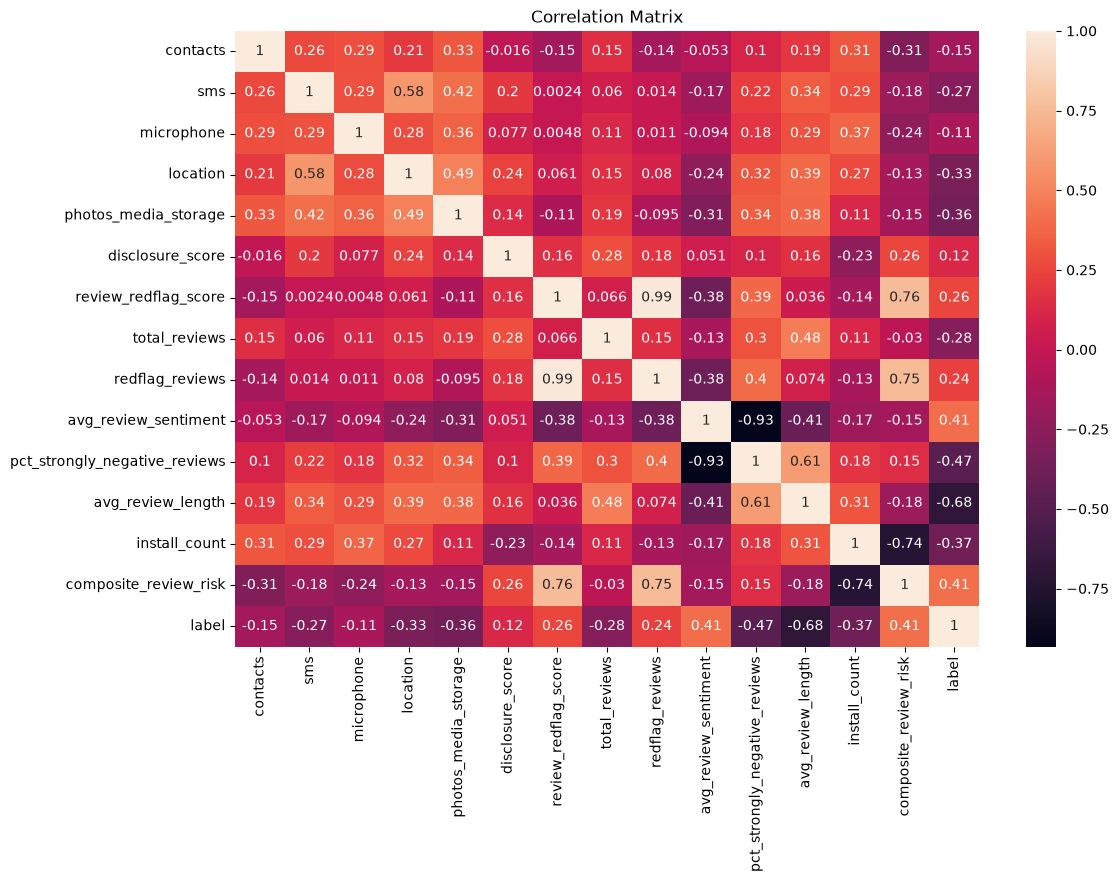

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop(columns=["app_id","app_name"]).corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [21]:
df.groupby("label")["disclosure_score"].mean()

label
0    3.000000
1    3.377778
Name: disclosure_score, dtype: float64

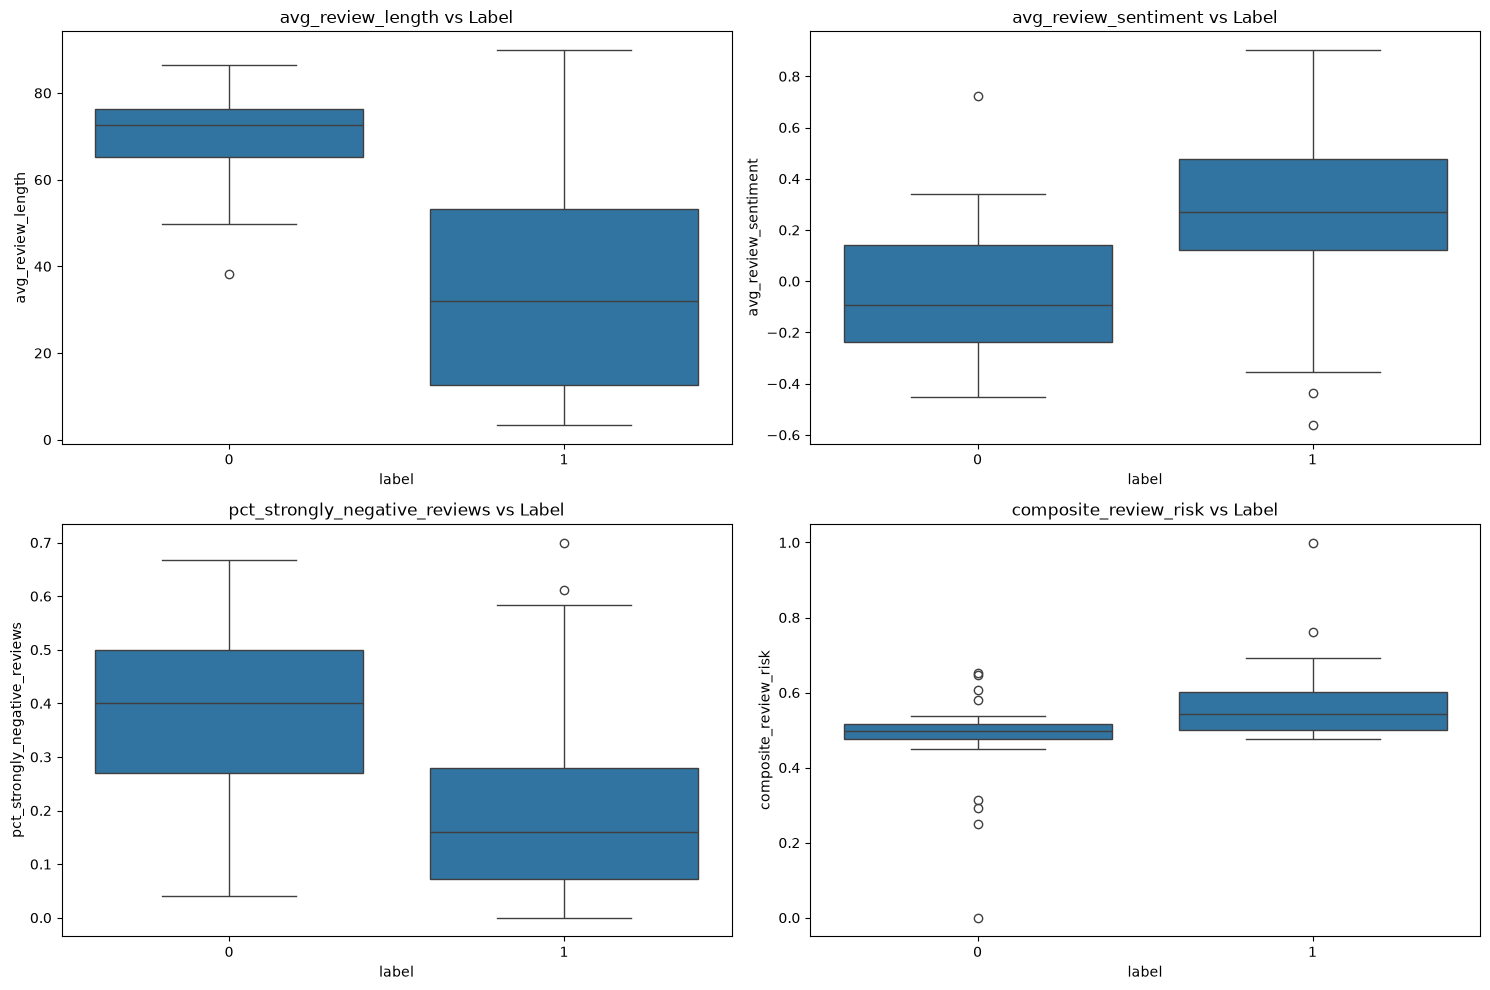

In [22]:
important_features = [
    "avg_review_length",
    "avg_review_sentiment",
    "pct_strongly_negative_reviews",
    "composite_review_risk"
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(important_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x="label", y=feature)
    plt.title(f"{feature} vs Label")

plt.tight_layout()
plt.show()

### Feature Selection and Trainn test splitting

In [23]:
X = df.drop(columns=["app_id", "app_name", "label","total_reviews","redflag_reviews", "composite_review_risk"])
y = df["label"]

In [24]:
X.head()

,contacts,sms,microphone,location,photos_media_storage,disclosure_score,review_redflag_score,avg_review_sentiment,pct_strongly_negative_reviews,avg_review_length,install_count
0,0,1,0,1,1,5,0.043,-0.258111,0.468085,45.744681,1000000
1,0,0,0,1,1,4,0.080,0.160420,0.240000,32.000000,1000000
2,1,0,0,0,0,2,0.040,0.295790,0.200000,34.520000,500000
3,0,1,0,1,0,5,0.060,0.370418,0.180000,75.880000,10000000
4,1,0,1,0,1,4,0.000,0.625962,0.040000,40.880000,500000


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Model Training

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [27]:
numeric_features = [
    "contacts",
    "sms",
    "microphone",
    "location",
    "photos_media_storage",
    "disclosure_score",
    "review_redflag_score",
    "avg_review_sentiment",
    "pct_strongly_negative_reviews",
    "avg_review_length",
    "install_count"
]

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

In [29]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42,max_iter=1000))
])
dt_pipeline = Pipeline([
    ("classifier", DecisionTreeClassifier(random_state=42))
])
rf_pipeline = Pipeline([
    ("classifier", RandomForestClassifier(random_state=42))
])
xgb_pipeline = Pipeline([
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [30]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}
results = []
for model_name, model in models.items():

    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring
    )
    results.append({
        "Model": model_name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1 Score": cv_results["test_f1"].mean()
    })
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.783333,0.882828,0.803571,0.816998
2,Random Forest,0.800000,0.866667,0.828571,0.816330
3,XGBoost,0.783333,0.872727,0.828571,0.810643
0,Logistic Regression,0.783333,0.866667,0.800000,0.800945


### Tuning the top 3 models: Logistic Regression, XGBoost and RandomForest

In [32]:
lr_params = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

tuned_results = []
tuned_results.append({
    "Model": "Logistic Regression",
    "Best CV F1": lr_grid.best_score_,
    "Best Parameters": lr_grid.best_params_
})

In [33]:
rf_params = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)
rf_grid.fit(X_train, y_train)

tuned_results.append({
    "Model": "Random Forest",
    "Best CV F1": rf_grid.best_score_,
    "Best Parameters": rf_grid.best_params_
})

In [34]:
xgb_params = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__max_depth": [3, 5]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

xgb_grid.fit(X_train, y_train)

tuned_results.append({
    "Model": "XGBoost",
    "Best CV F1": xgb_grid.best_score_,
    "Best Parameters": xgb_grid.best_params_
})

In [35]:
tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.sort_values(by="Best CV F1", ascending=False)
tuned_df

,Model,Best CV F1,Best Parameters
0,Logistic Regression,0.865943,"{'classifier__C': 0.1, 'classifier__class_weig..."
1,Random Forest,0.841784,"{'classifier__max_depth': None, 'classifier__m..."
2,XGBoost,0.820000,"{'classifier__learning_rate': 0.01, 'classifie..."


### Final Model Evaluation ( Logistic Regression)

In [36]:
y_pred = lr_grid.best_estimator_.predict(X_test)

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.89      0.89      0.89         9

    accuracy                           0.88        16
   macro avg       0.87      0.87      0.87        16
weighted avg       0.88      0.88      0.88        16



In [38]:
y_prob = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.3f}")

ROC-AUC Score: 0.937


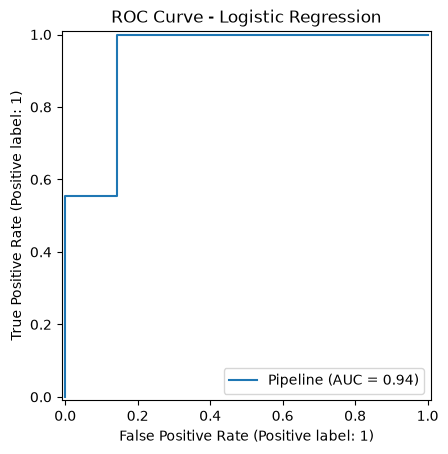

In [39]:
RocCurveDisplay.from_estimator(
    lr_grid.best_estimator_,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

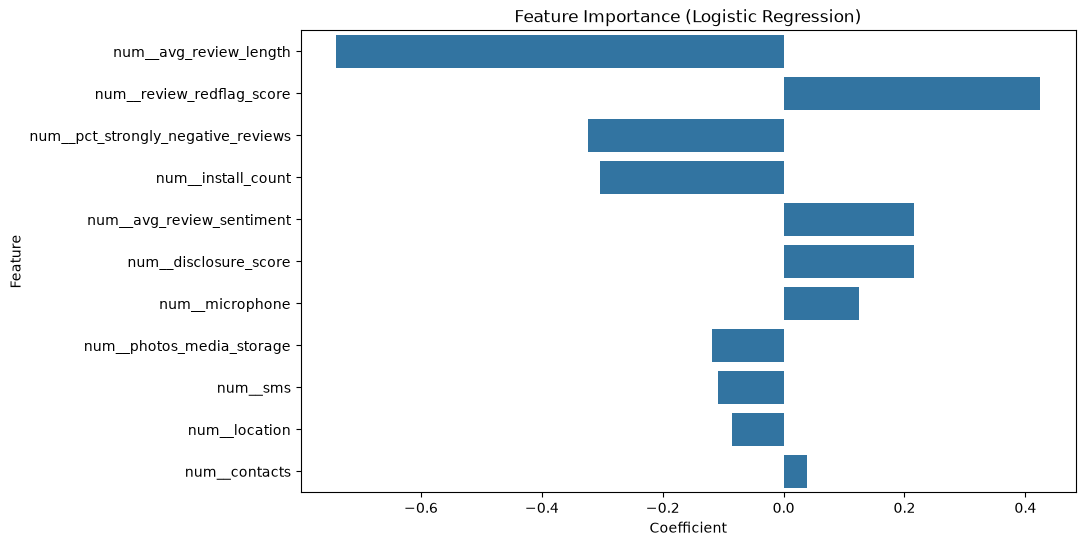

In [40]:
lr_model = lr_grid.best_estimator_.named_steps["classifier"]

coefficients = lr_model.coef_[0]

feature_names = lr_grid.best_estimator_\
    .named_steps["preprocessor"]\
    .get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df["Absolute Coefficient"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Logistic Regression)")
plt.show()

In [41]:
final_model = lr_grid.best_estimator_
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['contacts','sms','microphone',...,'pct_strongly_negative_reviews', 'avg_review_length','install_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [42]:
import joblib

joblib.dump(final_model, "predatory_loan_detector.pkl")

['predatory_loan_detector.pkl']